## DATA 620 Project 3

### Introduction

Using the NLTK names corpus, we would like to figure out how to create the best possible classifier to tell if a name is male or female. In Chapter 6 of Natural Language Programming with Python, we are shown Naive Bayes, Decision Trees, and Maximum Entropy as potential classifiers. Besides choosing a base classifier, we will improve our model by creating and applying features.



In [78]:
# imports
import random
import nltk
nltk.download('names')
from nltk.corpus import names
from nltk.classify import accuracy
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score
from collections import Counter

# Load and shuffle names
labeled_names = ([(name, 'male') for name in names.words('male.txt')] +
                 [(name, 'female') for name in names.words('female.txt')])
random.seed(123) # For reproducibility
random.shuffle(labeled_names)

[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


Start with the process demonstrated in the textbook's sample. Get the names and label them if they are found in either the male or female lists.


In [79]:
# Create the initial DataFrame for display and intermediate steps
df_labeled_names = pd.DataFrame(labeled_names, columns=['name', 'gender'])


As this process will be done iteratively, we will have multiple functions predefined to keep the process more consistent.

In [80]:
def generate_and_split_name_datasets(labeled_names_list, feature_extractor):
    featuresets = [(feature_extractor(name), gender) for (name, gender) in labeled_names_list]

    # Split the data into test, devtest, and train sets with fixed sizes
    test_size = 500
    devtest_size = 500

    test_set = featuresets[:test_size]
    devtest_set = featuresets[test_size : test_size + devtest_size]
    train_set = featuresets[test_size + devtest_size :]

    return test_set, devtest_set, train_set

def evaluate_classifier_full_metrics(classifier, dataset, label_encoder=None):
    # Extract actual labels and features
    actual_labels = [label for (features, label) in dataset]

    # Get predictions (most likely class)
    predictions = [classifier.classify(features) for (features, label) in dataset]

    print('--- Classifier Performance Metrics ---')

    # Accuracy Score
    accuracy = accuracy_score(actual_labels, predictions)
    print(f'Accuracy: {accuracy:.4f}\n')

    # Classification Report
    print('Classification Report:')
    print(classification_report(actual_labels, predictions))

    # ROC Curve and AUC (for binary classification)
    # Check if the classifier supports probability estimation
    if hasattr(classifier, 'prob_classify'):
        probas = []
        for features, _ in dataset:
            dist = classifier.prob_classify(features)
            # Ensure 'female' and 'male' labels are handled correctly
            female_prob = dist.prob('female') if 'female' in dist.samples() else 0.0
            probas.append(female_prob)

        # Map 'female' to 1 and 'male' to 0
        binary_actual_labels = [1 if label == 'female' else 0 for label in actual_labels]

        fpr, tpr, _ = roc_curve(binary_actual_labels, probas)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc='lower right')
        plt.show()
        print(f'AUC (Area Under the Curve): {roc_auc:.4f}')
    else:
        print("\nNote: This classifier does not support probability estimation, so ROC curve and AUC cannot be calculated.")

def identify_misclassifications(classifier, dataset):
    false_positives_data = [] # Predicted 'female', Actual 'male'
    false_negatives_data = [] # Predicted 'male', Actual 'female'

    for features, actual_label in dataset:
        predicted_label = classifier.classify(features)

        # Initialize a dictionary for the current misclassified entry
        entry = {
            'Name': features.get('name', 'N/A'),
            'Actual': actual_label,
            'Predicted': predicted_label
        }

        # Dynamically add all other features from the 'features' dictionary
        # Exclude 'name' as it's already handled as a primary identifier
        for feature_key, feature_value in features.items():
            if feature_key != 'name':
                # Format feature key for better display in DataFrame
                entry[feature_key.replace('_', ' ').title()] = feature_value

        if actual_label == 'male' and predicted_label == 'female':
            false_positives_data.append(entry)
        elif actual_label == 'female' and predicted_label == 'male':
            false_negatives_data.append(entry)

    # Convert lists of dictionaries to DataFrames
    fp_df = pd.DataFrame(false_positives_data)
    fn_df = pd.DataFrame(false_negatives_data)

    print('--- False Positives (Predicted Female, Actual Male) ---')
    display(fp_df.head())

    print('\n--- False Negatives (Predicted Male, Actual Female) ---')
    display(fn_df.head())
    return fp_df, fn_df

# Function to calculate accuracy for a given dataset
def calculate_accuracy(classifier, dataset):
    if not dataset:
        return 0.0
    actual_labels = [label for (features, label) in dataset]
    predictions = [classifier.classify(features) for (features, label) in dataset]
    return accuracy_score(actual_labels, predictions)


This will act as our code library for this analysis. We have:
* `generate_and_split_name_datasets`: Dynamically get features from the dataset to use in the classification process. Assume that we have already presplit the datasets so that each iteration of the classifier is being evaluated equally.
* `evaluate_classifier_full_metrics`: Compile a number of common classification metrics such as accuracy, a classification report (precision, recall, F1-score, etc.), and a ROC curve.
* `identify_misclassifications`: Check the mistakes to see if there are any obvious trends in how the classifier is failing.
* `calculate_accuracy`: Extra accuracy helper for when we do not need to calculate a full report.

In [81]:
# Consolidated Feature Extractors

def initial_feature_extractor(name):
    return {'name': name}

def androgynous_feature_extractor(name):
    features = initial_feature_extractor(name)
    features['is_androgynous'] = 1 if name in common_names else 0
    return features

def last_letter_extractor(name):
    features = initial_feature_extractor(name)
    features['last_letter'] = name[-1].lower()
    return features

def suffix_extractor(name):
    features = last_letter_extractor(name)
    features['last_two_letters'] = name[-2:].lower() if len(name) >= 2 else name.lower()
    return features

def prefix_suffix_extractor(name):
    features = suffix_extractor(name)
    features['first_letter'] = name[0].lower()
    return features

def bigram_extractor(name):
    features = prefix_suffix_extractor(name)
    name_lower = name.lower()
    for i in range(len(name_lower) - 1):
        features['bigram_' + name_lower[i:i+2]] = True
    return features

def trigram_extractor(name):
    features = bigram_extractor(name)
    name_lower = name.lower()
    for i in range(len(name_lower) - 2):
        features['trigram_' + name_lower[i:i+3]] = True
    return features

def fourgram_extractor(name):
  features = trigram_extractor(name)
  name_lower = name.lower()
  for i in range(len(name_lower) - 3):
      features['fourgram_' + name_lower[i:i+4]] = True
  return features

def fourgram_androgynous_extractor(name):
    features = fourgram_extractor(name) # Start with 4-gram features
    features['is_androgynous'] = 1 if name in common_names else 0
    return features

We are consolidating the feature extractors to make it easier to find where to fix the code per iteration. Generally, each function is related to the next step that potentially improved the classifier's performance:

*   `initial_feature_extractor`: Adds only the name itself.
*   `androgynous_feature_extractor`: Adds a boolean feature indicating if the name is found in both male and female lists.
*   `last_letter_extractor`: Adds the last letter of the name.
*   `suffix_extractor`: Adds the last two letters (suffix) and the last letter of the name.
*   `prefix_suffix_extractor`: Adds the first letter, last two letters, and last letter of the name.
*   `bigram_extractor`: Adds bigrams (two-letter sequences) from the name, along with prefix and suffix features.
*   `trigram_extractor`: Adds trigrams (three-letter sequences) from the name, along with bigram, prefix and suffix features.
*   `fourgram_extractor`: Adds four-grams (four-letter sequences) from the name, along with the features in the trigram extractor.
*   `fourgram_androgynous_extractor`: Combines all features made including is_androgynous.

In [82]:
# Calculate and display the total male and female names in the original labeled_names list
gender_counts = Counter(gender for name, gender in labeled_names)
display(gender_counts)

# Also display the percentage distribution
print('\nPercentage Distribution:')
total_names = sum(gender_counts.values())
for gender, count in gender_counts.items():
    print(f"{gender}: {(count / total_names) * 100:.2f}%")

# Call the new function to get the datasets
test_set, devtest_set, train_set = generate_and_split_name_datasets(labeled_names, initial_feature_extractor)

# Train the classifier (this part remains outside as it uses the output of the function)
init_nb_classifier = nltk.NaiveBayesClassifier.train(train_set)

Counter({'female': 5001, 'male': 2943})


Percentage Distribution:
female: 62.95%
male: 37.05%


We will start with no special features for a baseline model. Such a classifier will likely overpredict for the majority class which is female with over 60% presence.

Percentage Distribution:
* female: 62.95%
* male: 37.05%

The initial classifier uses Naive Bayes because it is fast and efficient. It assumes independence of features which is irrelevant for now since we do not have any features. We may need to revisit the classifier choice later on depending on chosen features.

--- Classifier Performance Metrics ---
Accuracy: 0.5800

Classification Report:
              precision    recall  f1-score   support

      female       0.61      0.92      0.73       314
        male       0.00      0.00      0.00       186

    accuracy                           0.58       500
   macro avg       0.30      0.46      0.37       500
weighted avg       0.38      0.58      0.46       500



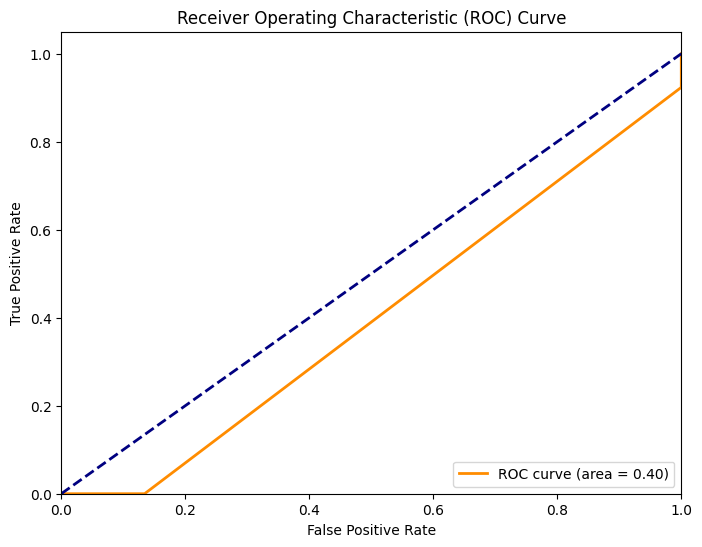

AUC (Area Under the Curve): 0.3997


In [83]:
# Call the classifier analysis function for the devtest set
evaluate_classifier_full_metrics(init_nb_classifier, devtest_set)

Our initial Naive-Bayes classifier without any unique features is very poor. This is by design to show off the need to create features. The ROC curve isn't even a curve as actual male names were never correctly labeled male (no true negatives as shown by 0% recall). An accuracy of 58% is close to a coinflip when there are only two possible answers.

In [84]:
# Identify misclassifications on the initial devtest set
misclassified_fp_init, misclassified_fn_init = identify_misclassifications(init_nb_classifier, devtest_set)

--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted
0,Dugan,male,female
1,Park,male,female
2,Ferinand,male,female
3,Lawrence,male,female
4,Muffin,male,female



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted
0,Daffy,female,male
1,Sam,female,male
2,Eddie,female,male
3,Virgie,female,male
4,Saundra,female,male


One notable potential issue in the incorrect results is that Sam is predicted to be male, but considered female. While Sam can be short for Samantha, it could also be short for Samuel. Sam is a common androgynous name.

In [85]:
sam_gender = df_labeled_names[df_labeled_names['name'].str.lower() == 'sam']
display(sam_gender)

,name,gender
507,Sam,female
4861,Sam,male


Sure enough, in the original data, the name exists as both male and female. This can disrupt the classification process. One way to keep the names while accounting for this issue is to create a feature that points out if a name is androgynous or not.

In [86]:
male_names_corpus = set(names.words('male.txt'))
female_names_corpus = set(names.words('female.txt'))

common_names = male_names_corpus.intersection(female_names_corpus)

print(f'Number of names appearing in both male and female NLTK lists: {len(common_names)}')
print(f'First 10 common names: {list(common_names)[:10]}')

Number of names appearing in both male and female NLTK lists: 365
First 10 common names: ['Claude', 'Maddie', 'Lind', 'Isador', 'Billie', 'Valentine', 'Nichole', 'Darryl', 'Mel', 'Teddie']


We have 365 total androgynous names divided across our names corpus.

Let's test the classifier with our first engineered feature: `is_androgynous`. This is a good test of the modularity of our functions for further feature engineering as well. However, there is a strong chance that this does not dramatically improve our classifier on its own. 365 is a low amount of affected names relative to our total list.

--- Classifier Performance Metrics ---
Accuracy: 0.5760

Classification Report:
              precision    recall  f1-score   support

      female       0.61      0.90      0.73       314
        male       0.12      0.02      0.04       186

    accuracy                           0.58       500
   macro avg       0.36      0.46      0.38       500
weighted avg       0.43      0.58      0.47       500



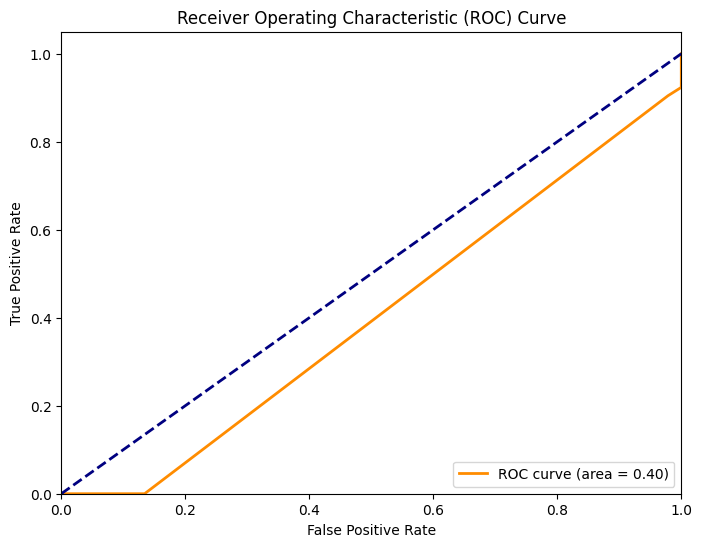

AUC (Area Under the Curve): 0.4014


In [87]:
# Regenerate datasets with the 'is_androgynous' feature
test_set_androgynous, devtest_set_androgynous, train_set_androgynous = generate_and_split_name_datasets(labeled_names, androgynous_feature_extractor)

# Train a new classifier with the updated feature sets
androgynous_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_androgynous)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(androgynous_nb_classifier, devtest_set_androgynous)

As expected, the performance is still very poor and virtually unchanged if we evaluate raw statistics like accuracy and the AUC. However, if we look in the classification report, we find that recall has changed from 92% female and 0% male to 90% female and 2% male. The classifier traded away some of its ability to predict female names, but can now predict male names very slightly. We will remove this feature for now, but maybe we can revisit it after trying more definitive features.

A popular feature for improving classification is the last letter of a name. English names are derived from numerous different languages. Often these other languages have trends such as Spanish names ending in 'o' when male and 'a' when female. In other words, the majority of a name can be similar, but the last letter alone is the deciding factor. We will iterate our classifier using this knowledge.

<Figure size 1500x800 with 0 Axes>

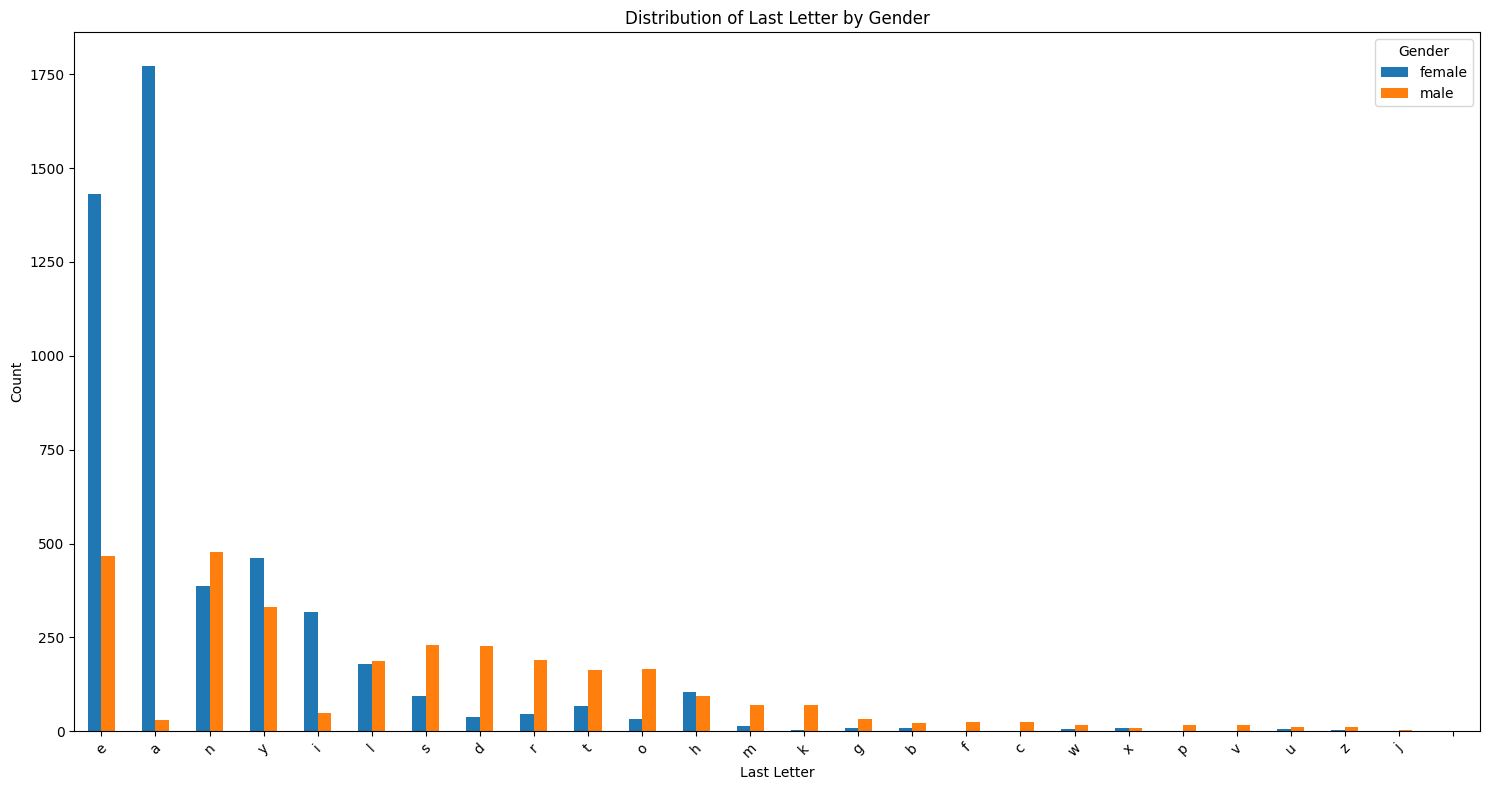

In [88]:
# Create a temporary DataFrame for plotting last letter distribution
df_temp_last_letter = df_labeled_names.copy()
df_temp_last_letter['last_letter'] = df_temp_last_letter['name'].apply(lambda x: x[-1].lower())

# Calculate the distribution of last_letter by gender
last_letter_distribution = df_temp_last_letter.groupby(['last_letter', 'gender']).size().unstack(fill_value=0)

# Sort by total count of each letter for better visualization
last_letter_distribution['total'] = last_letter_distribution['female'] + last_letter_distribution['male']
last_letter_distribution = last_letter_distribution.sort_values(by='total', ascending=False).drop(columns='total')

# Plotting the distribution
fig = plt.figure(figsize=(15, 8))
last_letter_distribution.plot(kind='bar', figsize=(15, 8))
plt.title('Distribution of Last Letter by Gender')
plt.xlabel('Last Letter')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

`e`, `a`, and `i` are very clear indicators of female names. Common male name endings seem to be consonants more often with `n`, `s`, `d`, `r`, and `t` being among the most frequent and more lopsided results (besides `n`). We should see a strong improvement in our classifier's performance.

--- Classifier Performance Metrics ---
Accuracy: 0.7300

Classification Report:
              precision    recall  f1-score   support

      female       0.80      0.76      0.78       314
        male       0.63      0.68      0.65       186

    accuracy                           0.73       500
   macro avg       0.71      0.72      0.72       500
weighted avg       0.74      0.73      0.73       500



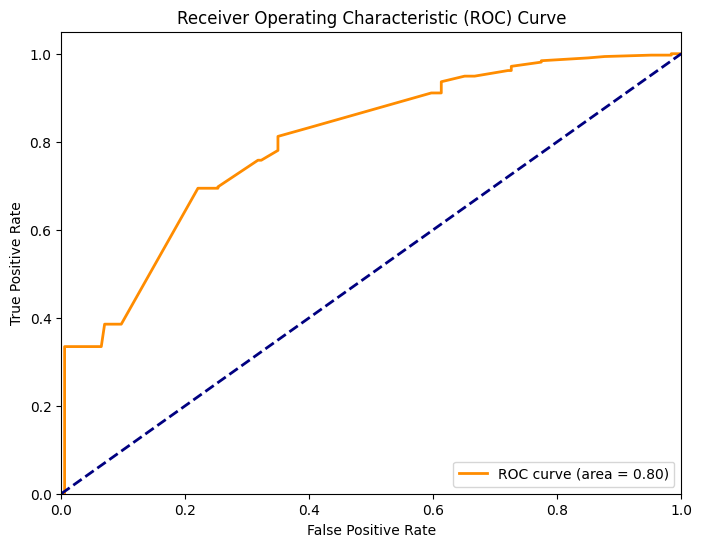

AUC (Area Under the Curve): 0.7994
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter
0,Lawrence,male,female,e
1,Muffin,male,female,n
2,Saxe,male,female,e
3,Juanita,male,female,a
4,Zane,male,female,e



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter
0,Annabal,female,male,l
1,Daffy,female,male,y
2,Sam,female,male,m
3,Margo,female,male,o
4,Eddie,female,male,e


In [89]:
# Regenerate datasets with the last_letter features
test_set_last_letter, devtest_set_last_letter, train_set_last_letter = generate_and_split_name_datasets(labeled_names, last_letter_extractor)

# Train a new classifier with the updated feature sets
last_letter_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_last_letter)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(last_letter_nb_classifier, devtest_set_last_letter)

# Identify misclassifications to see how the last_letter features influence errors
misclassified_fp_last_letter, misclassified_fn_last_letter = identify_misclassifications(last_letter_nb_classifier, devtest_set_last_letter)

Our ROC curve now looks like a curve when using `last_letter` as a predictive feature. Male names are found correctly 68% of the time now. A 73% overall accuracy and 0.797 AUC exhibit strong predictive abilities. Recall dropped for female names, but the overall changes in the metrics show that the classifier is "smarter" now instead of heavily defaulting to the majority class.

In [90]:
# found = False
# for features, label in train_set_last_letter:
#     if features.get('name') == 'Sam' and label == 'male':
#         found = True
#         break

# if found:
#     print("'Sam, male' is present in the training set.")
# else:
#     print("'Sam, male' is NOT present in the training set.")


<!-- The classifier still gets a high number of names wrong however. We may be able to improve this further. Sam is still a problematic name. This implies that androgynous names are still a major source of error for the classifier. If the training set has one name + label combination and the test set has the same name + opposite label, it'll always be wrong. -->

In [91]:
# def get_androgynous_status(feature_dict):
#     # This function assumes 'is_androgynous' is a key in the feature dictionary
#     return feature_dict.get('is_androgynous', 0)

# # Separate the devtest_set_last_letter into androgynous and non-androgynous subsets
# devtest_set_androgynous_only = []
# devtest_set_non_androgynous_only = []

# for features, label in devtest_set_last_letter:
#     if get_androgynous_status(features) == 1:
#         devtest_set_androgynous_only.append((features, label))
#     else:
#         devtest_set_non_androgynous_only.append((features, label))

# print(f"Number of androgynous names in devtest set: {len(devtest_set_androgynous_only)}")
# print(f"Number of non-androgynous names in devtest set: {len(devtest_set_non_androgynous_only)}")

# # Calculate accuracy for androgynous names
# accuracy_androgynous = calculate_accuracy(last_letter_nb_classifier, devtest_set_androgynous_only)
# print(f"Accuracy for androgynous names: {accuracy_androgynous:.4f}")

# # Calculate accuracy for non-androgynous names
# accuracy_non_androgynous = calculate_accuracy(last_letter_nb_classifier, devtest_set_non_androgynous_only)
# print(f"Accuracy for non-androgynous names: {accuracy_non_androgynous:.4f}")

<!-- It is unsurprising that a significant amount of the trouble with the classifier is tied to androgynous names. Unfortunately, there aren't any clear ways to get around this currently. We will look for other ways to improve accuracy for now. -->

In [103]:
last_letter_nb_classifier.show_most_informative_features(10)

Most Informative Features
             last_letter = 'a'            female : male   =     33.3 : 1.0
             last_letter = 'k'              male : female =     29.2 : 1.0
             last_letter = 'p'              male : female =     18.6 : 1.0
             last_letter = 'f'              male : female =     15.2 : 1.0
             last_letter = 'v'              male : female =      9.8 : 1.0
             last_letter = 'd'              male : female =      9.8 : 1.0
             last_letter = 'm'              male : female =      9.2 : 1.0
             last_letter = 'o'              male : female =      8.0 : 1.0
             last_letter = 'w'              male : female =      8.0 : 1.0
             last_letter = 'r'              male : female =      6.7 : 1.0


Last letter is the primary indicator for our classifier. This demonstrates what we learned from the earlier bar graph, but focuses on the likelihood rather than the frequency of that letter.

As detailed in Chapter 6, the last letter isn't the only possible important one. There are also two letter endings that are common for names such as `ie` in Debbie or Marie.

--- Classifier Performance Metrics ---
Accuracy: 0.7660

Classification Report:
              precision    recall  f1-score   support

      female       0.84      0.78      0.81       314
        male       0.67      0.75      0.70       186

    accuracy                           0.77       500
   macro avg       0.75      0.76      0.76       500
weighted avg       0.77      0.77      0.77       500



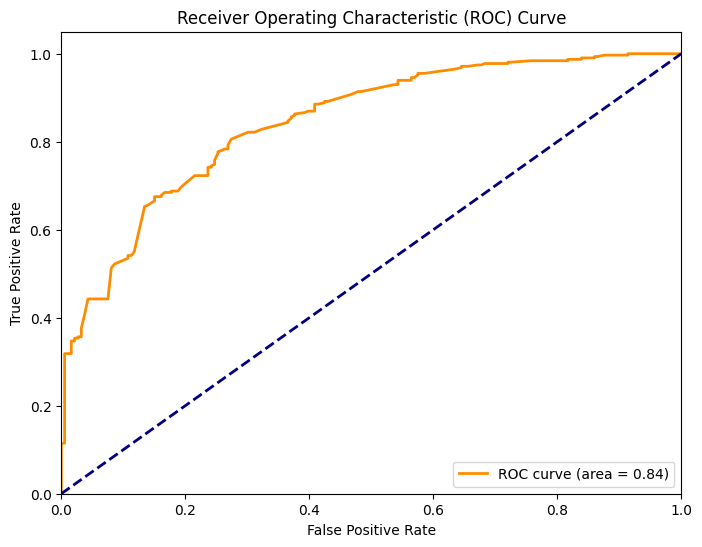

AUC (Area Under the Curve): 0.8437
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters
0,Lawrence,male,female,e,ce
1,Saxe,male,female,e,xe
2,Juanita,male,female,a,ta
3,Zane,male,female,e,ne
4,Sollie,male,female,e,ie



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters
0,Ulrike,female,male,e,ke
1,Annabal,female,male,l,al
2,Daffy,female,male,y,fy
3,Sam,female,male,m,am
4,Margo,female,male,o,go


In [93]:
# Regenerate datasets with the suffix features
test_set_suffix, devtest_set_suffix, train_set_suffix = generate_and_split_name_datasets(labeled_names, suffix_extractor)

# Train a new classifier with the updated feature sets
suffix_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_suffix)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(suffix_nb_classifier, devtest_set_suffix)

# Identify misclassifications to see how the suffix features influence errors
misclassified_fp_suffix, misclassified_fn_suffix = identify_misclassifications(suffix_nb_classifier, devtest_set_suffix)

With a 76.6% classification rate and 0.8437 AUC, this is the best performing classifier so far.

Using the last letter and last 2 letters brings up the initial question about classifier choice. We're now violating the assumption of independent features. We can compare the performance of these features using Maximum Entropy (MaxEnt).  

  ==> Training (10 iterations)

      Iteration    Log Likelihood    Accuracy
      ---------------------------------------
             1          -0.69315        0.371
             2          -0.31625        0.847
             3          -0.27455        0.890
             4          -0.24496        0.904
             5          -0.22211        0.924
             6          -0.20371        0.939
             7          -0.18855        0.952
             8          -0.17586        0.957
             9          -0.16509        0.960
         Final          -0.15585        0.961
--- Classifier Performance Metrics ---
Accuracy: 0.7320

Classification Report:
              precision    recall  f1-score   support

      female       0.77      0.82      0.79       314
        male       0.66      0.58      0.62       186

    accuracy                           0.73       500
   macro avg       0.71      0.70      0.71       500
weighted avg       0.73      0.73      0.73       500



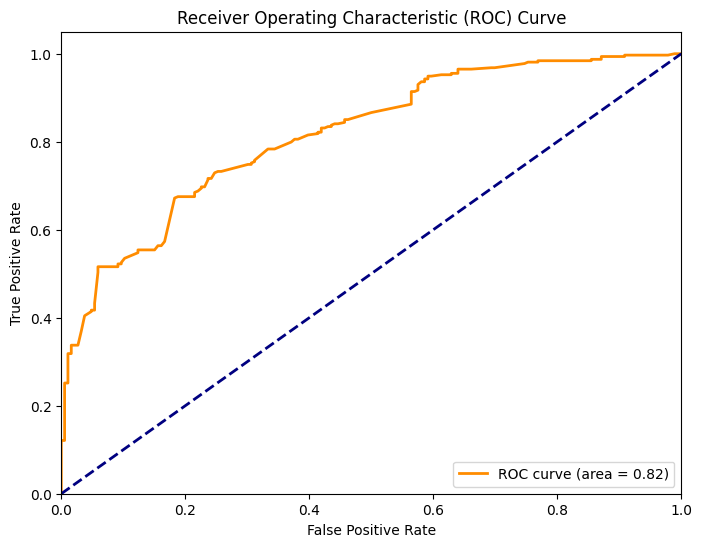

AUC (Area Under the Curve): 0.8166


In [94]:
maxent_classifier = nltk.MaxentClassifier.train(train_set_suffix, max_iter=10)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(maxent_classifier, devtest_set_suffix)

Most of the performance metrics slightly changed for MaxEnt with both suffix features, but recall for male dropped a larger amount from 0.75 to 0.58. It is not finding actual male names as well as before. The more general F1-score bears this difference too going from 0.70 to 0.62 for male names. We will stick with Naive Bayes.

It is not as obvious whether or not the first letter impacts a name's gender. We will check before creating this feature.

<Figure size 1500x800 with 0 Axes>

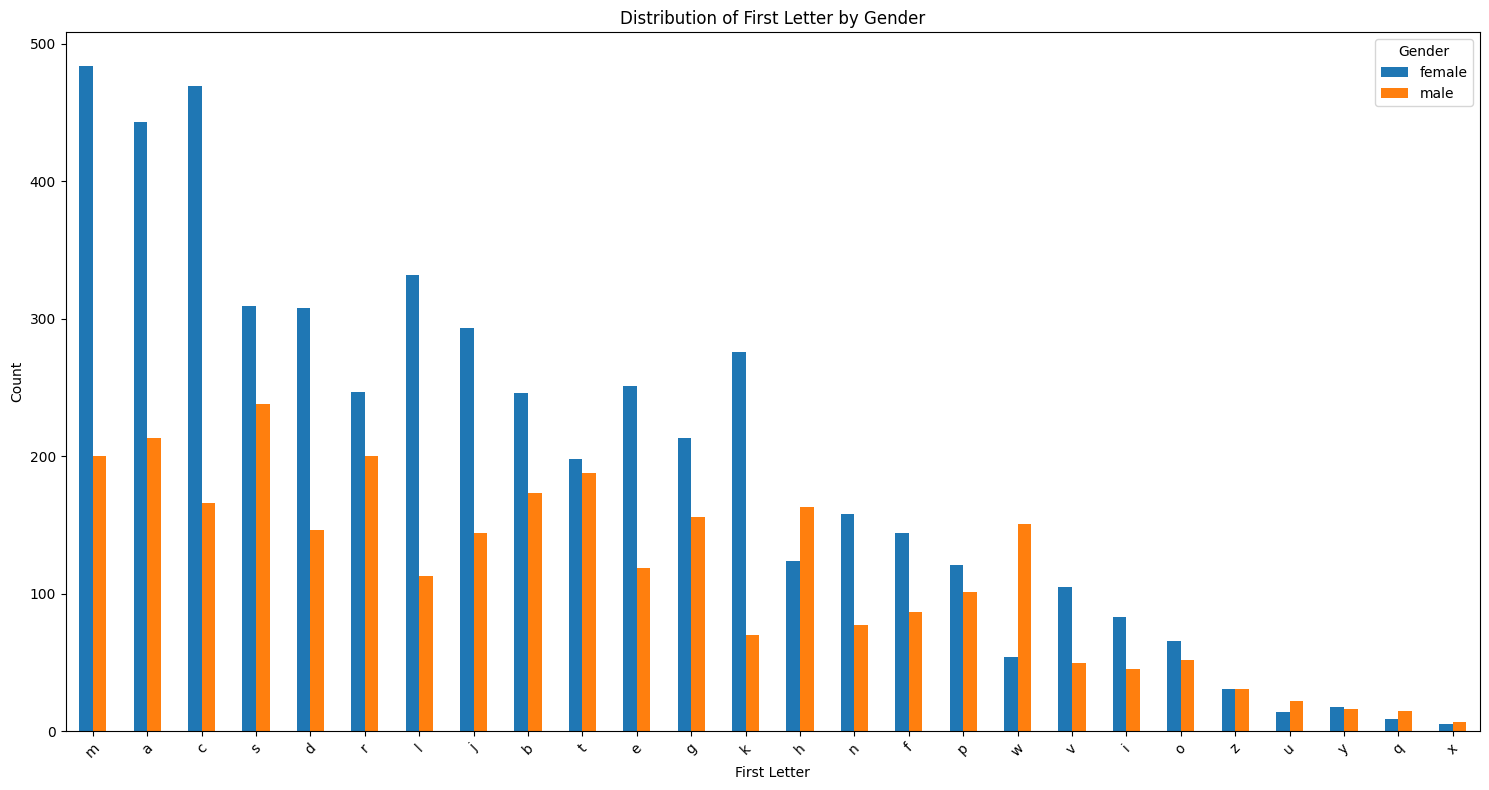

In [95]:
# Create a new DataFrame with a 'first_letter' feature
df_first_letter_temp = df_labeled_names.copy()
df_first_letter_temp['first_letter'] = df_first_letter_temp['name'].apply(lambda x: x[0].lower())

# Calculate the distribution of first_letter by gender
first_letter_distribution = df_first_letter_temp.groupby(['first_letter', 'gender']).size().unstack(fill_value=0)

# Sort by total count of each letter for better visualization
first_letter_distribution['total'] = first_letter_distribution['female'] + first_letter_distribution['male']
first_letter_distribution = first_letter_distribution.sort_values(by='total', ascending=False).drop(columns='total')

# Plotting the distribution
fig = plt.figure(figsize=(15, 8))
first_letter_distribution.plot(kind='bar', figsize=(15, 8))
plt.title('Distribution of First Letter by Gender')
plt.xlabel('First Letter')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

From the plot, we can observe that certain first letters are more common for one gender than the other, though the pattern might not be as strong as with the last letter. There does not seem to be many letters that were distinctly more frequently male than female. This feature would likely improve performance for female names more than male names.

--- Classifier Performance Metrics ---
Accuracy: 0.7860

Classification Report:
              precision    recall  f1-score   support

      female       0.85      0.80      0.82       314
        male       0.69      0.76      0.73       186

    accuracy                           0.79       500
   macro avg       0.77      0.78      0.78       500
weighted avg       0.79      0.79      0.79       500



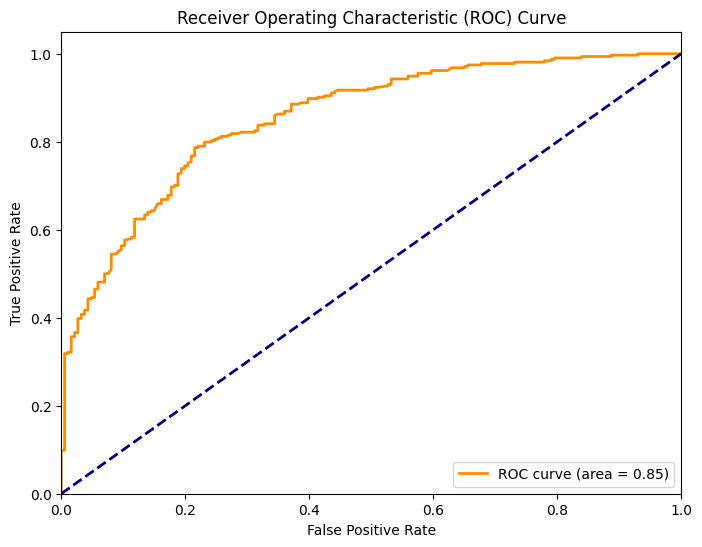

AUC (Area Under the Curve): 0.8532


In [96]:
# Regenerate datasets with the new set of features
test_set_prefix_suffix, devtest_set_prefix_suffix, train_set_prefix_suffix = generate_and_split_name_datasets(labeled_names, prefix_suffix_extractor)

prefix_suffix_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_prefix_suffix)


# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(prefix_suffix_nb_classifier, devtest_set_prefix_suffix)

We observe iterative improvements across most metrics over the suffix features by also including the first letter. We have 78.6% accuracy, 0.8532 AUC along with the highest F1-scores found so far for both genders.

The next few features are n-gram features based on combinations of letters together. A bigram would be 2 letters such as "la" or "wr" in "Lawrence".

--- Classifier Performance Metrics ---
Accuracy: 0.8080

Classification Report:
              precision    recall  f1-score   support

      female       0.86      0.83      0.84       314
        male       0.73      0.77      0.75       186

    accuracy                           0.81       500
   macro avg       0.79      0.80      0.80       500
weighted avg       0.81      0.81      0.81       500



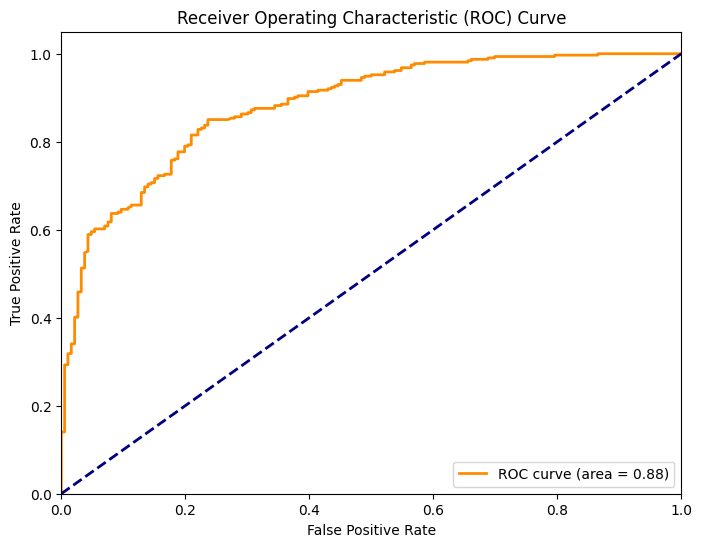

AUC (Area Under the Curve): 0.8819
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Ju,Bigram Ua,Bigram An,Bigram Ni,...,Bigram Je,Bigram Es,Bigram Ss,Bigram Ee,Bigram Pa,Bigram As,Bigram Sc,Bigram At,Bigram Th,Bigram Il
0,Juanita,male,female,a,ta,j,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fabian,male,female,n,an,f,NaN,NaN,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Zane,male,female,e,ne,z,NaN,NaN,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Dylan,male,female,n,an,d,NaN,NaN,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sollie,male,female,e,ie,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Ul,Bigram Lr,Bigram Ri,Bigram Ik,...,Bigram Aw,Bigram Wn,Bigram Io,Bigram La,Bigram As,Bigram Id,Bigram Gr,Bigram Rt,Bigram Es,Bigram Ny
0,Ulrike,female,male,e,ke,u,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Daffy,female,male,y,fy,d,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sam,female,male,m,am,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Margo,female,male,o,go,m,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vicky,female,male,y,ky,v,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
# Regenerate datasets with the bigram features
test_set_bigram, devtest_set_bigram, train_set_bigram = generate_and_split_name_datasets(labeled_names, bigram_extractor)

# Train a new classifier with the updated feature sets
bigram_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_bigram)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(bigram_nb_classifier, devtest_set_bigram)

# Identify misclassifications to see how the bigram features influence errors
misclassified_fp_bigram, misclassified_fn_bigram = identify_misclassifications(bigram_nb_classifier, devtest_set_bigram)

Again, there is small incremental but clear improvement. At 80.8% this is the first time our accuracy has surpassed 80%. We will continue with trigrams as certain name patterns around the world can reach 3 or even 4 letters.

--- Classifier Performance Metrics ---
Accuracy: 0.8240

Classification Report:
              precision    recall  f1-score   support

      female       0.87      0.85      0.86       314
        male       0.76      0.78      0.77       186

    accuracy                           0.82       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.83      0.82      0.82       500



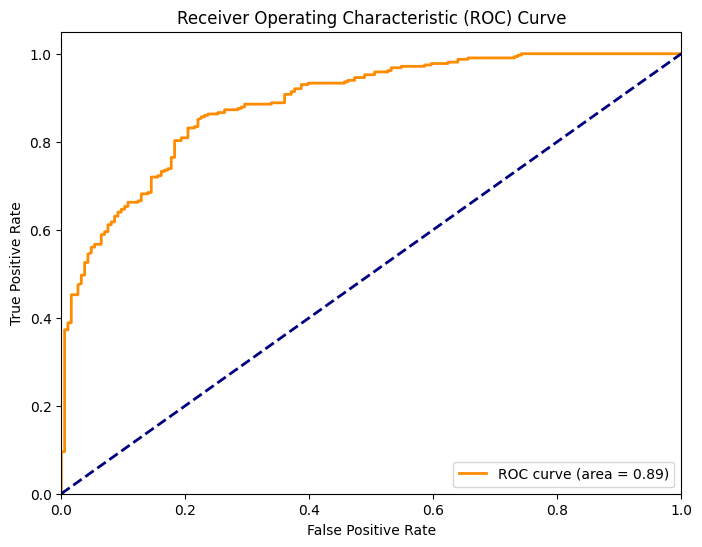

AUC (Area Under the Curve): 0.8877
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Fe,Bigram Er,Bigram Ri,Bigram In,...,Trigram Nat,Trigram Ath,Trigram Tha,Trigram Iel,Bigram Em,Bigram Il,Trigram Emi,Trigram Mil,Trigram Ile,Trigram Rie
0,Ferinand,male,female,d,nd,f,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Juanita,male,female,a,ta,j,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fabian,male,female,n,an,f,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Zane,male,female,e,ne,z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dylan,male,female,n,an,d,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Ul,Bigram Lr,Bigram Ri,Bigram Ik,...,Bigram Rt,Trigram Ert,Bigram Ny,Trigram Enn,Trigram Nny,Bigram Rd,Bigram Ys,Trigram Ard,Trigram Rdy,Trigram Dys
0,Ulrike,female,male,e,ke,u,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Daffy,female,male,y,fy,d,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sam,female,male,m,am,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Margo,female,male,o,go,m,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vicky,female,male,y,ky,v,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
# Regenerate datasets with the trigram features
test_set_trigram, devtest_set_trigram, train_set_trigram = generate_and_split_name_datasets(labeled_names, trigram_extractor)

# Train a new classifier with the updated feature sets
trigram_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_trigram)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(trigram_nb_classifier, devtest_set_trigram)

# Identify misclassifications to see how the trigram features influence errors
misclassified_fp_trigram, misclassified_fn_trigram = identify_misclassifications(trigram_nb_classifier, devtest_set_trigram)

            precision    recall      f1-score      support

      female       0.87      0.85      0.86       314
        male       0.76      0.78      0.77       186

These results show that female results may still be favored, but name predictions are very good for males too. The new 82.4% accuracy is now the highest seen.

Let's explore if including 4-gram features further improves our classifier's performance.

--- Classifier Performance Metrics ---
Accuracy: 0.8240

Classification Report:
              precision    recall  f1-score   support

      female       0.86      0.86      0.86       314
        male       0.76      0.77      0.76       186

    accuracy                           0.82       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.82      0.82      0.82       500



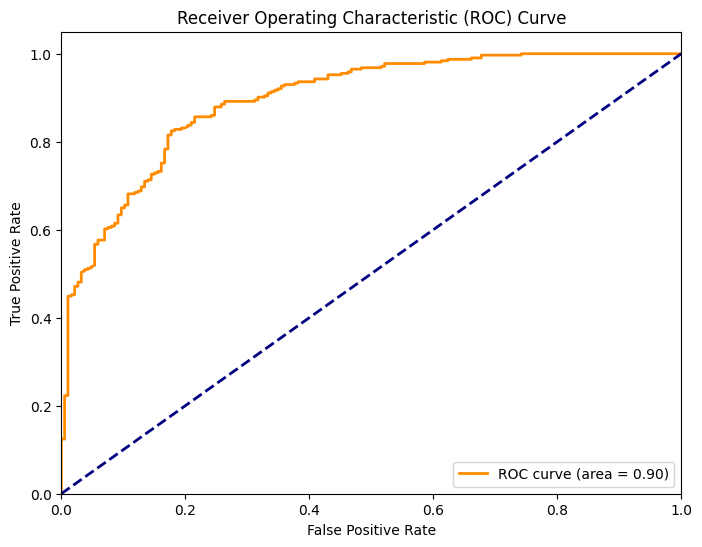

AUC (Area Under the Curve): 0.8954
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Fe,Bigram Er,Bigram Ri,Bigram In,...,Fourgram Anie,Fourgram Niel,Bigram Em,Trigram Emi,Trigram Mil,Trigram Ile,Fourgram Emil,Fourgram Mile,Trigram Rie,Fourgram Urie
0,Ferinand,male,female,d,nd,f,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Juanita,male,female,a,ta,j,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fabian,male,female,n,an,f,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Zane,male,female,e,ne,z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sollie,male,female,e,ie,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,...,Trigram Ard,Trigram Rdy,Trigram Dys,Fourgram Ardy,Fourgram Rdys
0,Ulrike,female,male,e,ke,...,NaN,NaN,NaN,NaN,NaN
1,Daffy,female,male,y,fy,...,NaN,NaN,NaN,NaN,NaN
2,Sam,female,male,m,am,...,NaN,NaN,NaN,NaN,NaN
3,Vicky,female,male,y,ky,...,NaN,NaN,NaN,NaN,NaN
4,Eddie,female,male,e,ie,...,NaN,NaN,NaN,NaN,NaN


In [104]:
# Regenerate datasets with the fourgram features
test_set_fourgram, devtest_set_fourgram, train_set_fourgram = generate_and_split_name_datasets(labeled_names, fourgram_extractor)

# Train a new classifier with the updated feature sets
fourgram_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_fourgram)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(fourgram_nb_classifier, devtest_set_fourgram)

# Identify misclassifications to see how the fourgram features influence errors
misclassified_fp_fourgram, misclassified_fn_fourgram = identify_misclassifications(fourgram_nb_classifier, devtest_set_fourgram)

The AUC improved from 0.8877 to 0.8954. The other classification metrics either remained the same or even slightly decreased for male recall. This improvement is questionable, but at least it tells us that it likely will not be worth trying a five-gram. Let's double check if we gain any value from reintroducing "is_androgynous" to our model.

--- Classifier Performance Metrics ---
Accuracy: 0.8280

Classification Report:
              precision    recall  f1-score   support

      female       0.87      0.86      0.86       314
        male       0.76      0.78      0.77       186

    accuracy                           0.83       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.83      0.83      0.83       500



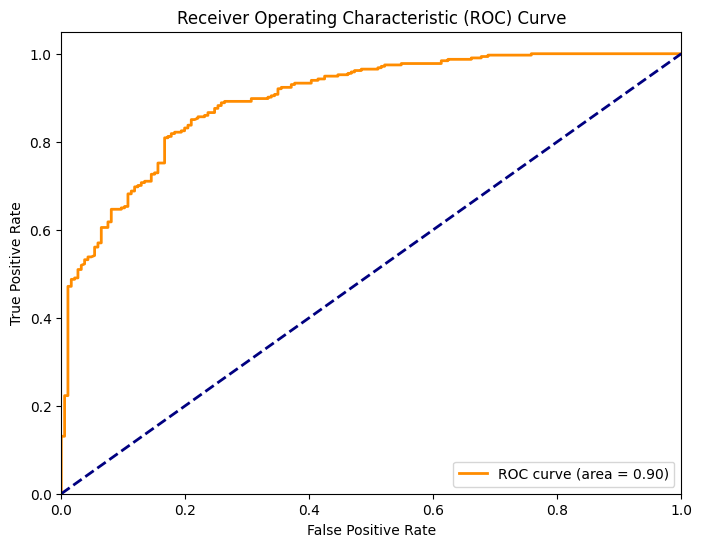

AUC (Area Under the Curve): 0.8966
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Fe,Bigram Er,Bigram Ri,Bigram In,...,Fourgram Anie,Fourgram Niel,Bigram Em,Trigram Emi,Trigram Mil,Trigram Ile,Fourgram Emil,Fourgram Mile,Trigram Rie,Fourgram Urie
0,Ferinand,male,female,d,nd,f,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Juanita,male,female,a,ta,j,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fabian,male,female,n,an,f,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Zane,male,female,e,ne,z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sollie,male,female,e,ie,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Ul,Bigram Lr,Bigram Ri,Bigram Ik,...,Trigram Nny,Fourgram Penn,Fourgram Enny,Bigram Rd,Bigram Ys,Trigram Ard,Trigram Rdy,Trigram Dys,Fourgram Ardy,Fourgram Rdys
0,Ulrike,female,male,e,ke,u,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Daffy,female,male,y,fy,d,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sam,female,male,m,am,s,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Vicky,female,male,y,ky,v,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Eddie,female,male,e,ie,e,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
# Regenerate datasets with combined fourgram and androgynous features
test_set_fourgram_androgynous, devtest_set_fourgram_androgynous, train_set_fourgram_androgynous = generate_and_split_name_datasets(labeled_names, fourgram_androgynous_extractor)

# Train a new classifier with the updated feature sets
fourgram_androgynous_nb_classifier = nltk.NaiveBayesClassifier.train(train_set_fourgram_androgynous)

# Evaluate the new classifier on the devtest set
evaluate_classifier_full_metrics(fourgram_androgynous_nb_classifier, devtest_set_fourgram_androgynous)

# Identify misclassifications
misclassified_fp_fourgram_androgynous, misclassified_fn_fourgram_androgynous = identify_misclassifications(fourgram_androgynous_nb_classifier, devtest_set_fourgram_androgynous)

Our latest model that includes all features did improvement slightly. It has the highest accuracy at 82.8%, an AUC of 0.8966, and F1-scores for females and male respectively at 0.86 and 0.77. It looks like while "is_androgynous" was not a strong primary feature on its own, on an already robust model it was able to help with some of the remaining issues.

In [106]:
all_features = fourgram_androgynous_nb_classifier.most_informative_features(20000)

# Define your target groups
groups = ['last_two', 'last_letter', 'bigram', 'trigram', 'fourgram', 'is_androgynous', 'first_letter', 'name']

def categorize_feature(feature_tuple):
    feature_name = str(feature_tuple[0])

    for prefix in groups:
        if feature_name.startswith(prefix):
            return prefix
    return 'other'

# Process every feature and count frequencies
feature_categories = [categorize_feature(f) for f in all_features]

# Create the sorted table
df = pd.Series(feature_categories).value_counts().reset_index()
df.columns = ['Feature Group', 'Frequency']

print(df.to_string(index=False))

 Feature Group  Frequency
      fourgram      14062
       trigram       4375
        bigram        932
          name        313
      last_two        264
   last_letter         26
  first_letter         26
is_androgynous          2


Taking the 20,000 most informative features, we see that fourgrams were the most recurring. Note that this isn't a proper percentage because a fourgram could be "ette" or "lune" in the name Lunette. The non-n-gram features could only occur once per word at most. This instead demonstrates that across a large enough sample, each feature had at least some moment when it was considered important enough for a classification.

Finally, we want to make sure that we did not overfit our dev data. Here is a test against data that we did not expose to the classifier until now:

--- Classifier Performance Metrics ---
Accuracy: 0.8180

Classification Report:
              precision    recall  f1-score   support

      female       0.85      0.86      0.86       320
        male       0.75      0.74      0.75       180

    accuracy                           0.82       500
   macro avg       0.80      0.80      0.80       500
weighted avg       0.82      0.82      0.82       500



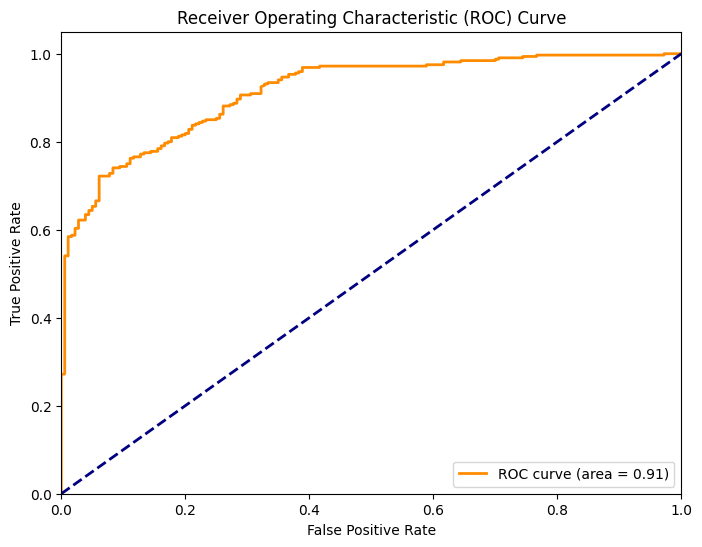

AUC (Area Under the Curve): 0.9138
--- False Positives (Predicted Female, Actual Male) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Do,Bigram On,Bigram Nn,Bigram Ny,...,Trigram Eas,Fourgram Phin,Fourgram Hine,Fourgram Inea,Fourgram Neas,Bigram Gl,Trigram Gle,Trigram Len,Fourgram Glen,Fourgram Lenn
0,Donny,male,female,y,ny,d,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Dennis,male,female,s,is,d,NaN,NaN,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Case,male,female,e,se,c,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Randal,male,female,l,al,r,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vinnie,male,female,e,ie,v,NaN,NaN,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- False Negatives (Predicted Male, Actual Female) ---


,Name,Actual,Predicted,Last Letter,Last Two Letters,First Letter,Bigram Do,Bigram Or,Bigram Ro,Bigram Ot,...,Fourgram Dorc,Fourgram Orca,Fourgram Rcas,Trigram Gai,Trigram Ail,Fourgram Gail,Trigram Lai,Trigram Air,Fourgram Blai,Fourgram Lair
0,Dorothy,female,male,y,hy,d,True,True,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Caitrin,female,male,n,in,c,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bertha,female,male,a,ha,b,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Easter,female,male,r,er,e,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Judy,female,male,y,dy,j,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
evaluate_classifier_full_metrics(fourgram_androgynous_nb_classifier, test_set_fourgram_androgynous)

fp_test, fn_test = identify_misclassifications(fourgram_androgynous_nb_classifier, test_set_fourgram_androgynous)

The performance was almost as good as the final dev set test when using the remaiming 500 words. 81.8% accuracy is a mild drop and the AUC actually improved to 0.9138, the highest observed.

## Conclusion

Patterns within names are strong indicators of a name's gender. While we started with the beginning and ends of names, we found that n-grams were also very important for catching any possible substring pattern within a name. The fact that names were potentially androgynous only affected a small number of names in our data, but checking for that helped with a little more refinement in cases where patterns could not determine the name's gender.

Our work was heavily focused and limited to just the information provided from the NLTK data. Improvements to the classifier would be expanding the options of base classifiers. Naive Bayes may have outperformed Maximum Entropy in this case and Decisions Trees proved to be too slow for to run iterations on, but there are many other options out there that are likely even better designed for NLP. Additionally, the patterns within names are typically based on language, so knowing the language a name is from can help clarify whether or not a pattern is important.

Presentation link: